ID: 2411872

Name: S. M. S. Morsalin

MAT203(Section-3)

Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import os

np.set_printoptions(precision=4, suppress=True)

Upload an image

In [ ]:
uploaded = files.upload()

image_path = next(iter(uploaded))
print("Image:", image_path)

# Open image and convert to grayscale
img = Image.open(image_path).convert("L")

# Convert image to matrix A
A = np.asarray(img, dtype=np.float64)

print("Image dimensions:", A.shape)
print("Matrix A shape:", A.shape)

Saving photo_6215241651173658009_y.jpg to photo_6215241651173658009_y.jpg
Image: photo_6215241651173658009_y.jpg
Image dimensions: (1280, 853)
Matrix A shape: (1280, 853)


Display the original grayscale image

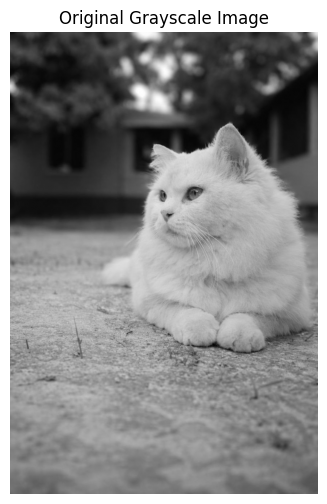

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(A, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

Compute SVD

In [ ]:
# A = U Sigma V^T
U, S, VT = np.linalg.svd(A, full_matrices=False)

print("Shape of U:", U.shape)
print("Number of singular values:", len(S))
print("Shape of VT:", VT.shape)

# Numerical rank
r = np.linalg.matrix_rank(A)

print("Rank of A =", r)

Shape of U: (1280, 853)
Number of singular values: 853
Shape of VT: (853, 853)
Rank of A = 853


Show singular values

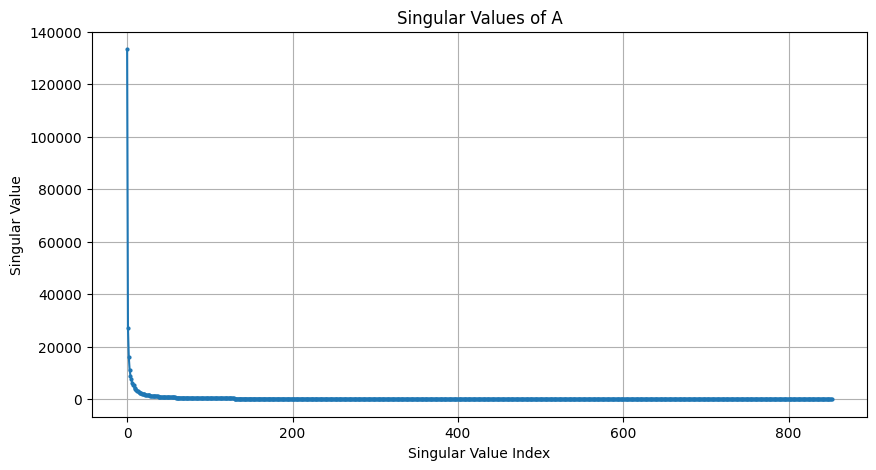

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(S, marker='o', markersize=2)
plt.title("Singular Values of A")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.grid(True)

plt.show()

Reconstruction function

In [ ]:
def reconstruct_image(U, S, VT, k):
    """
    Reconstruct an image using the top-k singular components.
    """
    k = min(k, len(S))

    Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

    # Keep pixel values in valid grayscale range
    Ak = np.clip(Ak, 0, 255)

    return Ak

Reconstruct for the required values of k

In [ ]:
k_values = [1, 5, 10, 20, 50, 100]

# Only use k values that are valid for this image
valid_k_values = [k for k in k_values if k <= r]

reconstructed_images = {}

for k in valid_k_values:
    reconstructed_images[k] = reconstruct_image(U, S, VT, k)

# Add full-rank reconstruction
reconstructed_images[r] = reconstruct_image(U, S, VT, r)

print("Reconstructions generated for:")
print(list(reconstructed_images.keys()))

Reconstructions generated for:
[1, 5, 10, 20, 50, 100, np.int64(853)]


Display all reconstructed images

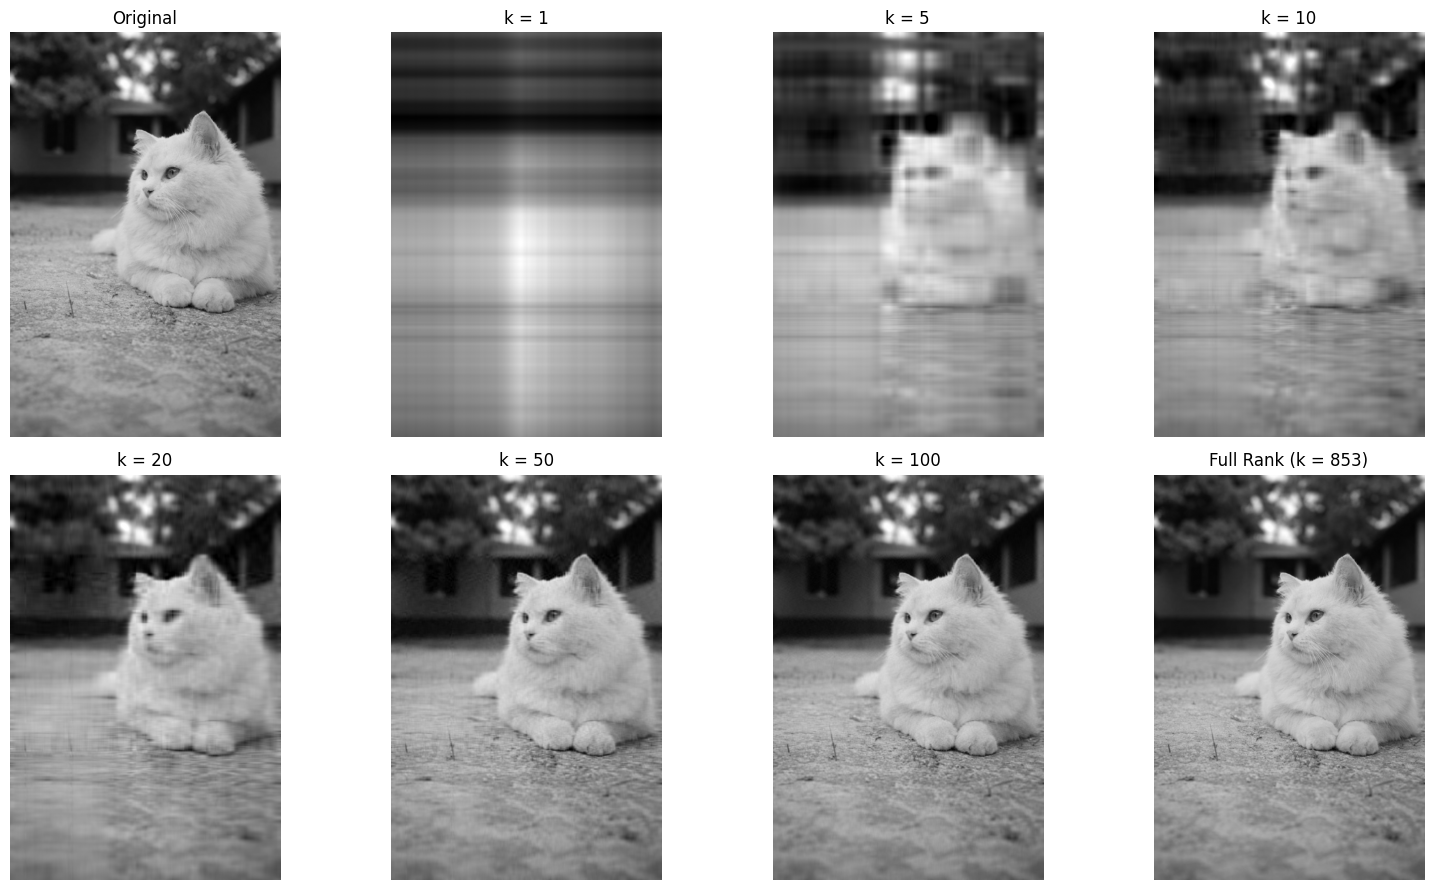

In [ ]:
num_images = len(reconstructed_images)

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

# Original image
axes[0].imshow(A, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, k in enumerate(valid_k_values, start=1):
    axes[i].imshow(reconstructed_images[k], cmap="gray")
    axes[i].set_title(f"k = {k}")
    axes[i].axis("off")

# Full-rank reconstruction
full_rank_position = len(valid_k_values) + 1

if full_rank_position < len(axes):
    axes[full_rank_position].imshow(
        reconstructed_images[r],
        cmap="gray"
    )
    axes[full_rank_position].set_title(f"Full Rank (k = {r})")
    axes[full_rank_position].axis("off")

# Hide unused axes
for j in range(full_rank_position + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Calculate reconstruction errors

In [ ]:
results = []

for k in valid_k_values + [r]:

    Ak = reconstructed_images[k]

    # Frobenius norm error
    error = np.linalg.norm(A - Ak, 'fro')

    # Relative reconstruction error
    relative_error = error / np.linalg.norm(A, 'fro')

    # Percentage of singular components retained
    percentage_components = (k / r) * 100

    results.append([
        k,
        error,
        relative_error,
        relative_error * 100,
        percentage_components
    ])

print(
    f"{'k':>8} "
    f"{'Frobenius Error':>20} "
    f"{'Relative Error':>20} "
    f"{'Error (%)':>15} "
    f"{'Components (%)':>18}"
)

print("-" * 90)

for row in results:
    print(
        f"{row[0]:>8} "
        f"{row[1]:>20.4f} "
        f"{row[2]:>20.6f} "
        f"{row[3]:>15.4f} "
        f"{row[4]:>18.2f}"
    )

       k      Frobenius Error       Relative Error       Error (%)     Components (%)
------------------------------------------------------------------------------------------
       1           39102.2627             0.281293         28.1293               0.12
       5           17963.3601             0.129225         12.9225               0.59
      10           12196.4840             0.087739          8.7739               1.17
      20            8328.9859             0.059917          5.9917               2.34
      50            4796.4558             0.034505          3.4505               5.86
     100            2872.9514             0.020667          2.0667              11.72
     853               0.0000             0.000000          0.0000             100.00


Display reconstruction quality with larger figures

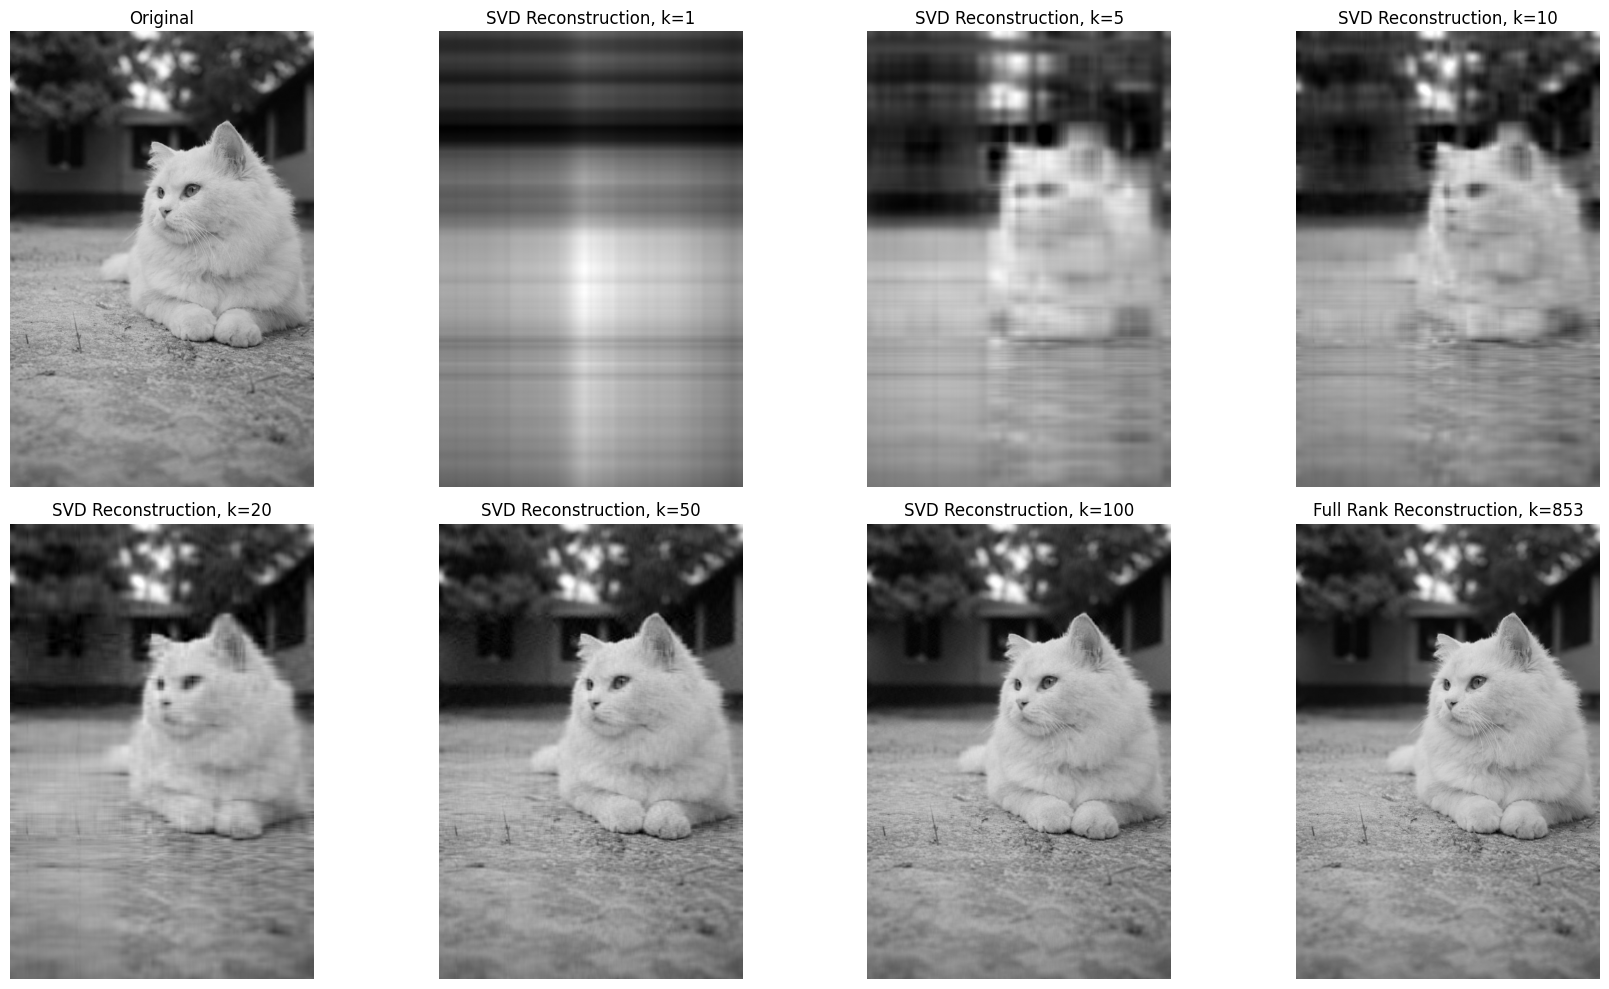

In [ ]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 10)
)

axes = axes.flatten()

axes[0].imshow(A, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, k in enumerate(valid_k_values):
    axes[i + 1].imshow(reconstructed_images[k], cmap="gray")
    axes[i + 1].set_title(f"SVD Reconstruction, k={k}")
    axes[i + 1].axis("off")

axes[len(valid_k_values) + 1].imshow(
    reconstructed_images[r],
    cmap="gray"
)
axes[len(valid_k_values) + 1].set_title(
    f"Full Rank Reconstruction, k={r}"
)
axes[len(valid_k_values) + 1].axis("off")

for i in range(len(valid_k_values) + 2, len(axes)):
    axes[i].axis("off")

plt.tight_layout()

# Save figure for the report
plt.savefig("svd_reconstructions.png", dpi=300, bbox_inches="tight")

plt.show()

results table

In [ ]:
import pandas as pd

df = pd.DataFrame(
    results,
    columns=[
        "k",
        "Frobenius Error",
        "Relative Error",
        "Error (%)",
        "Components Retained (%)"
    ]
)

df

,k,Frobenius Error,Relative Error,Error (%),Components Retained (%)
0,1,3.910226e+04,2.812934e-01,2.812934e+01,0.117233
1,5,1.796336e+04,1.292246e-01,1.292246e+01,0.586166
2,10,1.219648e+04,8.773892e-02,8.773892e+00,1.172333
3,20,8.328986e+03,5.991696e-02,5.991696e+00,2.344666
4,50,4.796456e+03,3.450469e-02,3.450469e+00,5.861665
5,100,2.872951e+03,2.066740e-02,2.066740e+00,11.723329
6,853,2.401014e-10,1.727239e-15,1.727239e-13,100.000000


retained information

Energy retained:
k =   1: 92.0874%
k =   5: 98.3247%
k =  10: 99.2278%
k =  20: 99.6405%
k =  50: 99.8809%
k = 100: 99.9573%
k = 853: 100.0000%


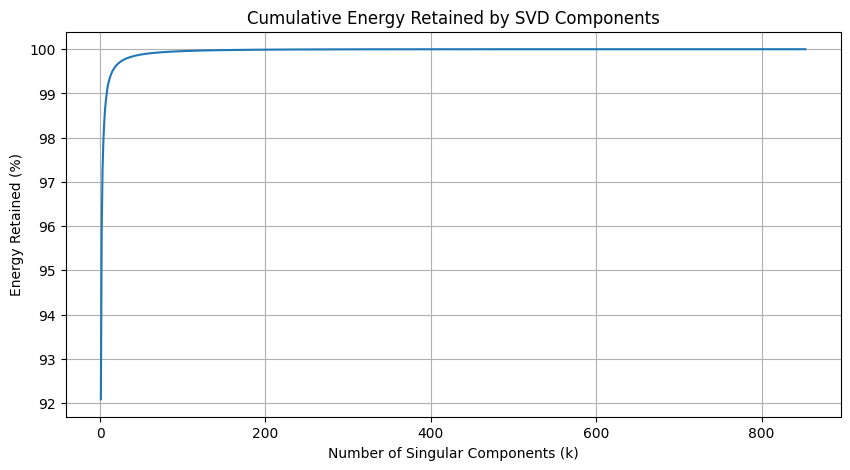

In [ ]:
energy = np.cumsum(S**2) / np.sum(S**2)

print("Energy retained:")

for k in valid_k_values + [r]:
    print(
        f"k = {k:3d}: "
        f"{energy[k-1] * 100:.4f}%"
    )

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(S) + 1),
    energy * 100
)

plt.xlabel("Number of Singular Components (k)")
plt.ylabel("Energy Retained (%)")
plt.title("Cumulative Energy Retained by SVD Components")
plt.grid(True)
plt.show()

# **discussion:**

Matrix A: grayscale image represented as a numerical matrix. SVD: A=UΣV T . Rank: r=rank(A), obtained using np.linalg.matrix_rank(A).

Low-rank reconstruction:

                            Ak = UkΣkVkT,
​
With k=1, only the dominant structure of the image is retained, so the reconstruction is very blurry.

Increasing k progressively restores edges, textures, and finer details.

At k=100, the reconstruction should generally be substantially closer to the original.

At k=r, the reconstruction should be essentially identical to the original grayscale matrix, apart from tiny floating-point/rounding differences.

The reconstruction error decreases as k increases.

The experiment demonstrates why SVD can be used for image compression and dimensionality

